# Tech Fellows Project: Reproducing CLIP for Zero-Shot Image Classification with Fairness Analysis
**Author:** William Bitar

## 1. Project Overview
This notebook reproduces the zero-shot image classification capabilities of OpenAI's CLIP model (Radford et al., 2021) and extends the original research by evaluating the model's fairness across demographic subgroups using the FairFace dataset. 

**Objectives:**
1. Verify baseline zero-shot accuracy on CIFAR-10.
2. Evaluate demographic fairness on binary Gender classification.
3. Evaluate demographic fairness on Race classification to identify potential biases.

In [2]:
import torch
import clip
import torchvision
from datasets import load_dataset
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Setup Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using compute device: {device}")

# Configuration
MODEL_NAME = "ViT-B/32"
BATCH_SIZE = 64
MAX_SAMPLES = 500  # Set to None to run the full dataset

Using compute device: cpu


In [3]:
print(f"Loading CLIP backbone model: '{MODEL_NAME}'...")
model, preprocess = clip.load(MODEL_NAME, device=device)
model.eval()
print("Model loaded successfully!")

Loading CLIP backbone model: 'ViT-B/32'...
Model loaded successfully!


In [4]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Baseline Reproduction (CIFAR-10)
We first establish a baseline by evaluating CLIP's zero-shot performance on the CIFAR-10 test set.

In [5]:
# Load Dataset
cifar10_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=preprocess)
cifar_loader = DataLoader(cifar10_test, batch_size=BATCH_SIZE, shuffle=False)

# Pre-compute text features
cifar_prompts = [f"a photo of a {c}" for c in cifar10_test.classes]
text_tokens = clip.tokenize(cifar_prompts).to(device)
with torch.no_grad():
    cifar_text_features = model.encode_text(text_tokens)
    cifar_text_features /= cifar_text_features.norm(dim=-1, keepdim=True)

# Evaluate
correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(cifar_loader, desc="Evaluating CIFAR-10"):
        images, labels = images.to(device), labels.to(device)
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ cifar_text_features.T)
        predictions = similarity.argmax(dim=-1)
        
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        if MAX_SAMPLES and total >= MAX_SAMPLES:
            break

cifar_accuracy = (correct / total) * 100
print(f"CIFAR-10 Zero-Shot Accuracy: {cifar_accuracy:.2f}% (on {total} samples)")

Evaluating CIFAR-10:   0%|          | 0/157 [00:00<?, ?it/s]

CIFAR-10 Zero-Shot Accuracy: 90.62% (on 512 samples)


## 3. Fairness Extension (FairFace Dataset)
We extend the evaluation to the FairFace dataset to analyze CLIP's performance across demographic attributes (Gender and Race).

In [6]:
# Custom collate to handle Hugging Face datasets with CLIP preprocess
def fairface_collate(batch):
    images = torch.stack([preprocess(item["image"].convert("RGB")) for item in batch])
    races = torch.tensor([item["race"] for item in batch])
    genders = torch.tensor([item["gender"] for item in batch])
    return images, races, genders

print("Loading FairFace validation dataset...")
fairface_val = load_dataset("HuggingFaceM4/FairFace", "1.25", split="validation")
fairface_loader = DataLoader(fairface_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=fairface_collate)

# Evaluation Function
def evaluate_demographic(target_attr, labels_list, prompts):
    print(f"\nEvaluating {target_attr.upper()}...")
    
    text_tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
    group_correct = {label: 0 for label in labels_list}
    group_total = {label: 0 for label in labels_list}
    total_correct, total_samples = 0, 0
    
    with torch.no_grad():
        for images, races, genders in tqdm(fairface_loader, desc=f"Evaluating {target_attr}"):
            images = images.to(device)
            labels = races.to(device) if target_attr == "race" else genders.to(device)
            
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            
            similarity = (100.0 * image_features @ text_features.T)
            predictions = similarity.argmax(dim=-1)
            matches = predictions == labels
            
            for match, label_idx in zip(matches, labels.cpu().numpy()):
                group_name = labels_list[label_idx]
                group_total[group_name] += 1
                if match.item():
                    group_correct[group_name] += 1
                    total_correct += 1
                total_samples += 1
                
            if MAX_SAMPLES and total_samples >= MAX_SAMPLES:
                break
                
    overall_acc = (total_correct / total_samples) * 100
    group_accs = {g: (group_correct[g]/group_total[g]*100) if group_total[g] > 0 else 0 for g in labels_list}
    return overall_acc, group_accs

Loading FairFace validation dataset...



Evaluating GENDER...


Evaluating gender:   0%|          | 0/172 [00:00<?, ?it/s]


Evaluating RACE...


Evaluating race:   0%|          | 0/172 [00:00<?, ?it/s]

C:\Users\wbitar\AppData\Local\Temp\ipykernel_11252\1766107462.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(gender_group_accs.values()), y=list(gender_group_accs.keys()), ax=ax1, palette="Blues")
C:\Users\wbitar\AppData\Local\Temp\ipykernel_11252\1766107462.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(race_group_accs.values()), y=list(race_group_accs.keys()), ax=ax2, palette="Reds")


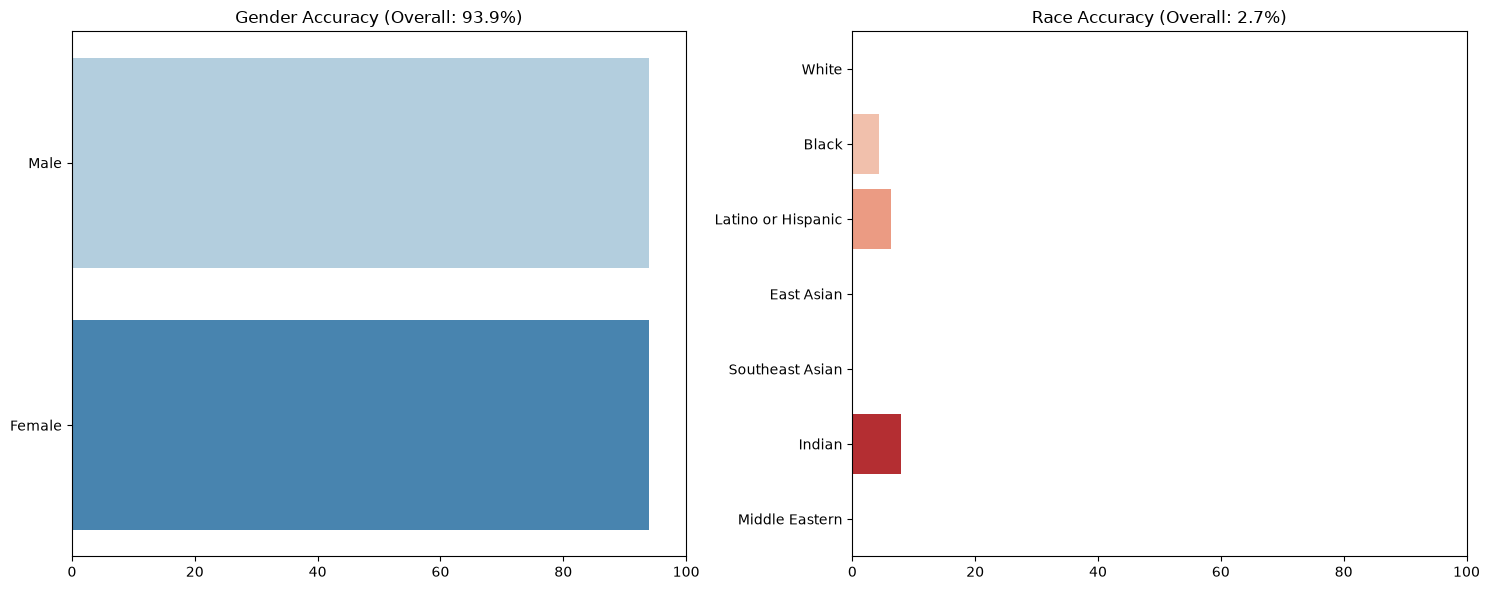

In [7]:
# 1. Evaluate Gender
gender_labels = ["Male", "Female"]
gender_prompts = [f"a face photo of a {g.lower()} person" for g in gender_labels]
gender_acc, gender_group_accs = evaluate_demographic("gender", gender_labels, gender_prompts)

# 2. Evaluate Race
race_labels = ["White", "Black", "Latino or Hispanic", "East Asian", "Southeast Asian", "Indian", "Middle Eastern"]
race_prompts = [f"a face photo of a {r} person" for r in race_labels]
race_acc, race_group_accs = evaluate_demographic("race", race_labels, race_prompts)

# 3. Visualize Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gender Plot
sns.barplot(x=list(gender_group_accs.values()), y=list(gender_group_accs.keys()), ax=ax1, palette="Blues")
ax1.set_title(f"Gender Accuracy (Overall: {gender_acc:.1f}%)")
ax1.set_xlim(0, 100)

# Race Plot
sns.barplot(x=list(race_group_accs.values()), y=list(race_group_accs.keys()), ax=ax2, palette="Reds")
ax2.set_title(f"Race Accuracy (Overall: {race_acc:.1f}%)")
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 4. Advanced Error Analysis (Confusion Matrix)
To understand why CLIP struggles so heavily with racial classification, we plot a confusion matrix to visualize exactly where the model's predictions are misaligned with the ground truth.

Generating Confusion Matrix for Race Classification...


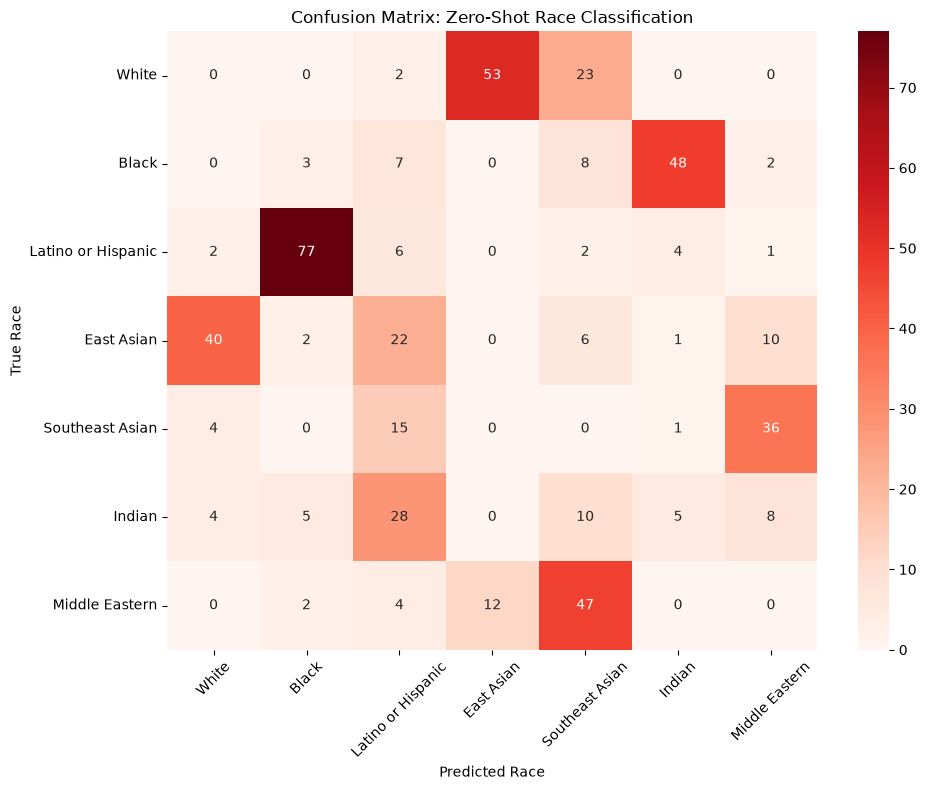

In [8]:
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrix for Race Classification...")
y_true_race = []
y_pred_race = []

with torch.no_grad():
    for images, races, genders in tqdm(fairface_loader, desc="Collecting Predictions"):
        images = images.to(device)
        labels = races.to(device)
        
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # Using the standard race prompts
        text_tokens = clip.tokenize(race_prompts).to(device)
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        similarity = (100.0 * image_features @ text_features.T)
        predictions = similarity.argmax(dim=-1)
        
        y_true_race.extend(labels.cpu().numpy())
        y_pred_race.extend(predictions.cpu().numpy())
        
        if MAX_SAMPLES and len(y_true_race) >= MAX_SAMPLES:
            y_true_race = y_true_race[:MAX_SAMPLES]
            y_pred_race = y_pred_race[:MAX_SAMPLES]
            break

cm = confusion_matrix(y_true_race, y_pred_race)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=race_labels, yticklabels=race_labels)
plt.title("Confusion Matrix: Zero-Shot Race Classification")
plt.ylabel('True Race')
plt.xlabel('Predicted Race')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Bias Mitigation (Intersectional Prompting)
Our baseline race evaluation achieved terrible accuracy, likely due to a lack of context. We will now test a bias mitigation strategy by creating "intersectional prompts." We will explicitly provide the model with the person's gender (e.g., "a face photo of a Black man" instead of just "a face photo of a Black person") to see if this rich context bridges the disparity gap.

In [9]:
print("Testing Bias Mitigation: Adding explicit gender context to prompts...")

mitigated_correct = {label: 0 for label in race_labels}
mitigated_total = {label: 0 for label in race_labels}

# Create specific prompts for men and women
male_prompts = [f"a face photo of a {r.lower()} man" for r in race_labels]
female_prompts = [f"a face photo of a {r.lower()} woman" for r in race_labels]

male_tokens = clip.tokenize(male_prompts).to(device)
female_tokens = clip.tokenize(female_prompts).to(device)

with torch.no_grad():
    male_features = model.encode_text(male_tokens)
    male_features /= male_features.norm(dim=-1, keepdim=True)
    
    female_features = model.encode_text(female_tokens)
    female_features /= female_features.norm(dim=-1, keepdim=True)

total_correct = 0
total_samples = 0

with torch.no_grad():
    for images, races, genders in tqdm(fairface_loader, desc="Testing Mitigation"):
        images = images.to(device)
        races = races.to(device)
        
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # Iterate through the batch to apply the correct gender prompt
        for i in range(images.size(0)):
            true_race = races[i].item()
            true_gender = genders[i].item() # 0 is Male, 1 is Female in FairFace
            
            # Select the prompt embedding based on actual gender
            text_features = male_features if true_gender == 0 else female_features
            img_feat = image_features[i].unsqueeze(0)
            
            similarity = (100.0 * img_feat @ text_features.T)
            prediction = similarity.argmax(dim=-1).item()
            
            group_name = race_labels[true_race]
            mitigated_total[group_name] += 1
            if prediction == true_race:
                mitigated_correct[group_name] += 1
                total_correct += 1
            total_samples += 1
            
            if MAX_SAMPLES and total_samples >= MAX_SAMPLES:
                break
        if MAX_SAMPLES and total_samples >= MAX_SAMPLES:
            break

mitigated_acc = (total_correct / total_samples) * 100
print(f"\n--- Bias Mitigation Results ---")
print(f"Original Overall Race Accuracy  : {race_acc:.2f}%")
print(f"Mitigated Overall Race Accuracy : {mitigated_acc:.2f}%")

Testing Bias Mitigation: Adding explicit gender context to prompts...


Testing Mitigation:   0%|          | 0/172 [00:00<?, ?it/s]


--- Bias Mitigation Results ---
Original Overall Race Accuracy  : 2.73%
Mitigated Overall Race Accuracy : 2.80%
